<a href="https://colab.research.google.com/github/Surendranmengineer/suren_test/blob/master/Telecom_Customer_Churn_Case_Study_EDA_with_Rajan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telcome Customer Churn Case Study
-----

You are provided with Telecome Customers Data , containing information about if they have Ported to Other network Or Not using `Churn` Field.

You are asked to do EDA and Find Insights / Reasonings Behind `Customer Churn`

In [ ]:
# Import Required Libararies

#  (please ignore matplotlib/seaborn for now )

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#matplotlib inline
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the Dataset

df = pd.read_csv('telco_churn.csv')

In [ ]:
# Preview Data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Inspection
----

In [ ]:
#  Rows/Cols Count
df.shape

(7043, 21)

In [ ]:
# Columns DataTypes
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# Statistical Summary about Numerical Columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# DataFrame Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Quality Check
----

# Find out the DataType of Column `TotalCharges` , is the right datatype if not What it is ?

In [ ]:
df['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [ ]:
df['TotalCharges'].dtype

dtype('O')

In [ ]:
# suggested Type: Float

In [ ]:
df['TotalCharges'] = df['TotalCharges'].astype('float')

ValueError: could not convert string to float: ' '

In [ ]:
df['TotalCharges'].value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [ ]:
df['TotalCharges']=pd.to_numeric( df['TotalCharges'] , errors='coerce')

In [ ]:
df['TotalCharges'].dtype

dtype('float64')

In [ ]:
# errors='coerce' means convert the non integer value i.e. spaces into Nulls

# Data Imbalance Check
----

In [ ]:
df['Churn'].head() # Can u find the data imbalance %age here?

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


In [ ]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


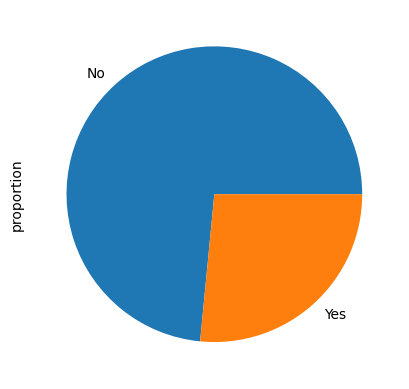

In [ ]:
df['Churn'].value_counts(normalize=True).plot(kind='pie');

# EDA Strategy
-----------------------------

<pre>

We are going to split the DataFrame into 2 Sub DataFrame where


df_leavers = 'contains records of customers who left the network'

df_customers = 'contains records of existing  customer '

later we shall compare their habbits eg. spending habits/gender etc to find out the impact on Churning.

In [ ]:
df_leavers = df[  df.Churn == 'Yes' ]

df_customers = df [ df.Churn == 'No' ]

In [ ]:
df_leavers['Churn'].head()

,Churn
2,Yes
4,Yes
5,Yes
8,Yes
13,Yes


In [ ]:
df_customers['Churn'].head()

,Churn
0,No
1,No
3,No
6,No
7,No


# Univariate Analysis
----

Univariate Analysis Means , Analysis using Single Variable/Field/Column.

Target Field : MonthlyCharges

Objective: to understand the monthly spending habbits of people ( leavers vs customers)

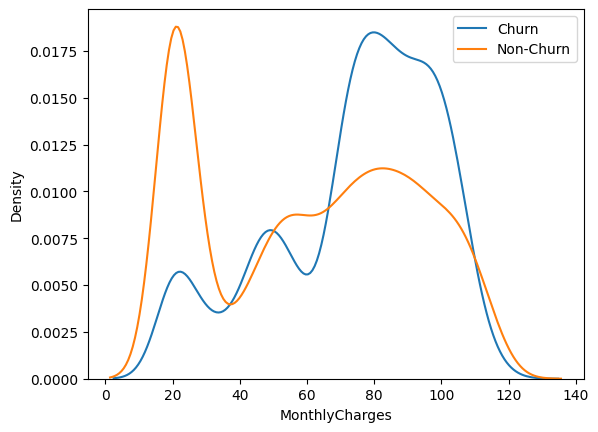

In [ ]:
sns.distplot( df_leavers['MonthlyCharges'] ,label='Churn',hist=False)
sns.distplot( df_customers['MonthlyCharges'] ,label='Non-Churn',hist=False)
plt.legend()
plt.show()

In [ ]:
df_leavers.MonthlyCharges.mean()

np.float64(74.44133226324237)

# Bivariate Analysis
----

Bivariate Analysis uses 2 Fields/Columns for  Analysis.

eg. Let us observe the distribution of Data by their ContractType and MonthlyCharges.

In [ ]:
df['Contract'].unique().tolist()

['Month-to-month', 'One year', 'Two year']

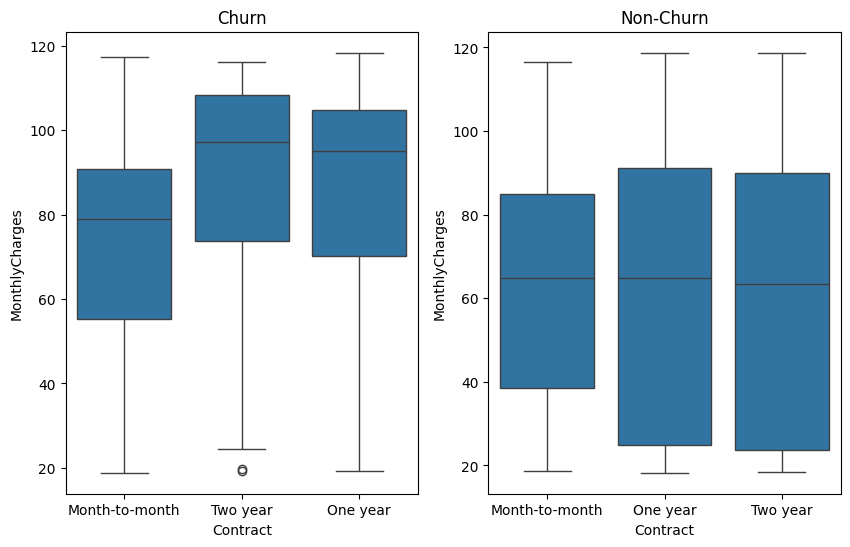

In [ ]:
# please ignore the code

plt.figure(figsize=(10,6))

plt.subplot(1,2,1)

plt.title('Churn')

sns.boxplot(x='Contract',y='MonthlyCharges', data=df_leavers)



plt.subplot(1,2,2)

plt.title('Non-Churn')

sns.boxplot(x='Contract',y='MonthlyCharges', data=df_customers)

plt.show()